<header style="background-color: rgb(0, 62, 92); color: white; margin-top: 20px; padding:28px; ">
  <img src="images/Xlogo.png" alt="Transposition of a vector" title="Vector transposition" width="115" style="float: left;">
  <p style=" text-align: center; font-size: 30px;">   
   <strong>  Stochastic calculus and control -  tutorial </strong></p>
  <p style=" text-align: center; font-size: 25px;"><strong> Stochastic Calculus </strong></p>
  <p style=" text-align: center; font-size: 20px;"> Eduardo Abi Jaber </p>
</header>


<p><strong><span style="color:rgb(0, 62, 92); font-size: 20px;">Who am I? 😎</span></strong></p>
<ul>
    <li><strong>Eduardo ABI JABER</strong></li>
    <li> Professor, Ecole Polytechnique 🤓</li>
</ul>

https://sites.google.com/view/abijabereduardo






# Why Randomness?  🤔

<img src="images/rock3.png" alt="Transposition of a vector" title="Vector transposition" width="700">


---

# Bachelier model


First stochastic model for the stock price has been introduced in 1903 by `Louis Bachelier` in his PhD thesis under the supervision of the celebrated  mathematician Henri Poincaré. 
	

<img src="images/Bachelier.jpg" alt="Transposition of a vector" title="Vector transposition" width="300" style="float: left;">
  <p style=" text-align: center; font-size: 20px;">   
    <strong> Louis Bachelier (1903) </strong></p> 
    <p style=" text-align: center; font-size: 14px;">$\bullet$ Bachelier is considered as the forefather of mathematical finance and a pioneer in the study of stochastic processes. </p>
    <p style=" text-align: center; font-size: 14px;"> $\bullet$  PhD not well received because it attempted to apply mathematics to an unfamiliar area for mathematicians
 </p>
    <p style=" text-align: center; font-size: 14px;">$\bullet$ Although Bachelier's work on random walks predated Einstein's celebrated study of Brownian motion by five years, the pioneering nature of his work was recognized only after several decades, first by Andrey Kolmogorov
 </p>  
 
 In the Bachelier model, the stock price is stochastic and follows a Brownian motion 
$$S_t = S_0  +  \sigma W_t, \quad t \leq T,  $$
where  $S_0>0$ is the initial price of the asset, $T$ is the investement horizon, and $\sigma>0$.


> What is a `Brownian motion` ?

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;"> 1. Zooming out a random walk 🔍
 </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

Given a family $\{Y_i,~i=1,\ldots,n\}$ of $n$ independent random variables with 
$$
	\mathbb P[Y_i=1]\;=\;1 - \mathbb P[Y_i=-1]
	=\frac{1}{2}
$$

we define the symmetric random walk
$$
M_0=0
	~\mbox{and}~
	M_{k} \;=\; \sum_{j=1}^k Y_j
	\quad \mbox{for}\quad 
	k=0,\ldots,n \,.
$$

By linear interpolation, define a continuous-time process:
$$
	M_t
	\;:=\; M_{\lfloor t\rfloor}
	+\left(t-\lfloor t\rfloor\right)M_{\lfloor t\rfloor+1}
	\quad \mbox{for}\quad 
	t\ge 0 \,,
$$
where $\lfloor t\rfloor$ denotes the largest integer less than or equal to $t$. 



Define a stochastic process $W^n$ by speeding up time and conveniently scaling:
$$
	W^n_t
	\quad :=\quad 
	\frac{1}{\sqrt{n}} M_{nt} \,,~~t\ge 0 \,.
$$
	
  
  1. Simulate trajectory of $M$ and $W^n$ for different $n$. 



In [1]:
import numpy as np
import matplotlib.pyplot as plt

[0. 1. 2. 1. 0. 1. 2. 3. 4. 5. 4. 3. 4. 3. 4. 5. 4. 3. 4. 3. 2.]


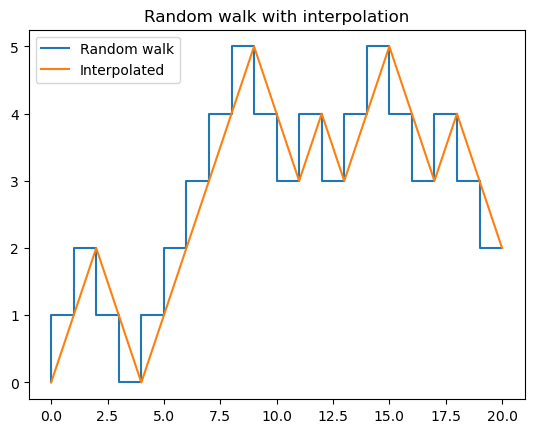

In [17]:
#Simulate M and interpolate

# number of jumps
n = 20

#Fix random number generator seed
np.random.seed(1)

#Simulate trajectory of m Start from M0=0 with concatenate
Mt = np.cumsum(np.concatenate(([0.],np.random.choice([-1,1],n))))

print(Mt)

plt.step(np.arange(n+1), Mt, label = 'Random walk')
plt.plot(np.arange(n+1),Mt, label ='Interpolated' )
plt.title('Random walk with interpolation')
plt.legend()
plt.show()

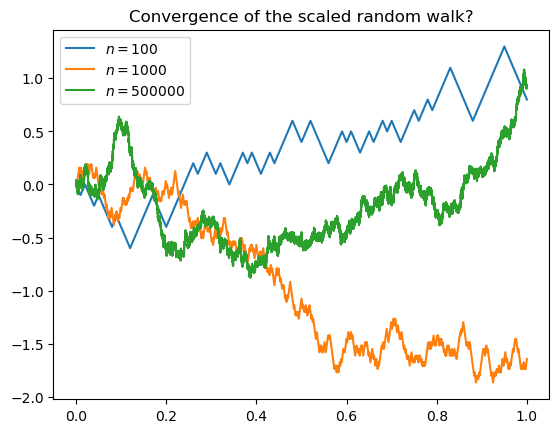

In [18]:
#Simulate M and interpolate

n0, n1, n2 = 100, 1000, 500000

Z0, Z1, Z2 = np.random.choice([-1,1], n0), np.random.choice([-1,1], n1), np.random.choice([-1,1], n2)
X0 = np.concatenate((np.zeros(1), Z0.cumsum())) / np.sqrt(n0)              #rescaled random walk with n0 steps
X1 = np.concatenate((np.zeros(1), Z1.cumsum())) / np.sqrt(n1)              #rescaled random walk with n1 steps
X2 = np.concatenate((np.zeros(1), Z2.cumsum())) / np.sqrt(n2)              #rescaled random walk with n2 steps

#Put on same x axis using linspace
plt.plot(np.linspace(0, 1, n0+1), X0, label = '$n = $' + str(n0) )
plt.plot(np.linspace(0, 1, n1+1), X1, label = '$n = $' + str(n1))
plt.plot(np.linspace(0, 1, n2+1), X2, label = '$n = $' + str(n2))
plt.legend()
plt.title("Convergence of the scaled random walk?")
plt.show()

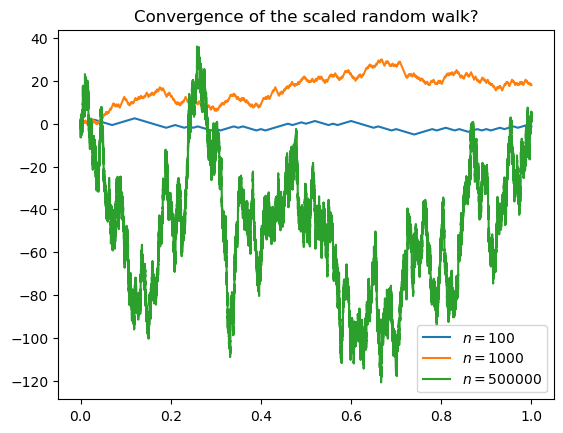

In [20]:
#playing with different scalings

n0, n1, n2 = 100, 1000, 500000

# scaling 1/n
Z0, Z1, Z2 = np.random.choice([-1,1], n0), np.random.choice([-1,1], n1), np.random.choice([-1,1], n2)
X0 = np.concatenate((np.zeros(1), Z0.cumsum())) / n0              #rescaled random walk with n0 steps
X1 = np.concatenate((np.zeros(1), Z1.cumsum())) / n1              #rescaled random walk with n1 steps
X2 = np.concatenate((np.zeros(1), Z2.cumsum())) / n2              #rescaled random walk with n2 steps

#scaling 1/n^0.1
Z0, Z1, Z2 = np.random.choice([-1,1], n0), np.random.choice([-1,1], n1), np.random.choice([-1,1], n2)
X0 = np.concatenate((np.zeros(1), Z0.cumsum())) / n0**0.1              #rescaled random walk with n0 steps
X1 = np.concatenate((np.zeros(1), Z1.cumsum())) / n1**0.1              #rescaled random walk with n1 steps
X2 = np.concatenate((np.zeros(1), Z2.cumsum())) / n2**0.1              #rescaled random walk with n2 steps


#Put on same x axis using linspace
plt.plot(np.linspace(0, 1, n0+1), X0, label = '$n = $' + str(n0) )
plt.plot(np.linspace(0, 1, n1+1), X1, label = '$n = $' + str(n1))
plt.plot(np.linspace(0, 1, n2+1), X2, label = '$n = $' + str(n2))
plt.legend()
plt.title("Convergence of the scaled random walk?")
plt.show()


We next set
$$
    t_{k} := \frac{k}{n} \ \mbox{ for } \ k \in \mathbb{N}.
$$
 

2. Prove the following properties of the process $W^n$:

* **Independence of increments** for $0 \leq i \leq j \leq k \leq \ell \leq n$, the increments $W_{t_{\ell}}^{n} - W_{t_{k}}^{n}$ and $W_{t_{j}}^{n} - W_{t_{i}}^{n}$ are independent,
* **First two moments** for $0 \leq i \leq k$, the two first moments of increment $W_{t_{k}}^{n} - W_{t_{i}}^{n}$ are given by 
$$
\mathbb{E}\left[W_{t_{k}}^{n} - W_{t_{i}}^{n}\right] = 0 ~~~\mbox{ and }~~~ \mathbb{V}{\rm ar}\left[W_{t_{k}}^{n} - W_{t_{i}}^{n}\right] = t_{k} - t_{i}.
$$
which shows in particular that the normalization by $n^{-1/2}$ in the definition of $W^n$ prevents the variance from blowing up,
* **Martingality** with $\mathcal{F}_{t}^{n} := \sigma(Y_{p}, p \leq \lfloor nt\rfloor)$ for $t \geq 0$, the sequence $\left\{W_{t_{k}}^{n}, k \in \mathbb{N}\right\}$ is a discrete $\left\{\mathcal{F}_{t_{k}}^{n}, k \in \mathbb{N}\right\}-$martingale:
$$
\mathbb{E}\left(W_{t_{k}}^{n} \mid \mathcal{F}_{t_{i}}^{n}\right) = W_{t_{i}}^{n} \ \ \mbox{ for } 0 \leq i \leq k \leq n.
$$
* **Quadratic variation**$$
\langle W^n, W^n\rangle_{t_{k}} := \sum_{j=1}^k \left(W_{t_{j}}^{n} - W_{t_{j-1}}^{n}\right)^2 = t_k.
$$

3. Explain why at the limit $n\to \infty$ Gaussian distribution of the increments is expected to hold?



> <p><strong><span style="color:rgb(0, 0, 255);">  The normalisation by $\sqrt{n}$ is suggested by Central Limit Theorem. 
By the so-called Donsker invariance principle, $(W^n_t)$ converges to
the standard Brownian motion as $n\to \infty$.  
</span><strong></p>  
   
    
> <p><strong><span style="color:rgb(0, 0, 255);">         Another interesting property of the rescaled random walk, which will be inherited by the Brownian motion, is the following quadratic variation result:
$$
\langle W^n, W^n\rangle_{t_{k}} = \sum_{j=1}^k \left(W_{t_{j}}^{n} - W_{t_{j-1}}^{n}\right)^2 = t_k.
$$
since $W_{t_{j}}^{n} - W_{t_{j-1}}^{n} \in \{-1, 1\}$. 
</span><strong></p>  


<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;"> 2. Brownian motion  🎲 </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

# Definition 

<div style="border:solid 1px; border-radius:8px; padding: 6px 8px 6px 8px; margin-top: 12px; border-color:rgb(0, 62, 92, 0.5); background-color:rgb(251, 251, 251);">
    <strong>Definition</strong>. (Brownian motion) 	Let $W=\{W_t,~t\in\mathbb R_+\}$ be a stochastic process on the probability space $(\Omega,\mathcal F,\mathbb P)$. $W$ is a standard Brownian motion if
    
- $W_0=0$ and the sample paths $W_.(\omega)$ are continuous for a.e. $\omega\in\Omega$,
- $W$ has independent increments: for all $0\leq t_1<t_2\leq t_3<t_4$, $W_{t_4}-W_{t_3}$ and $W_{t_2}-W_{t_1}$ are independent.
- For all $0\leq s<t$, the distribution of $W_t-W_s$ is  $N(0,t-s)$.
</div>



# Some properties 
The Brownian motion is the simplest example of a **Gaussian process**:
- A random variable $X\in \mathbb R$ is said to follow the **Gaussian distribution** $N(\mu,\sigma^2)$ if the law of $X$ has a density given by
$$
	p(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}
$$
- A random vector $(X_1,\dots,X_n)$ is a **Gaussian vector**
if for all $(a_1,\dots,a_n)\in \mathbb R^n$, $\sum_{i=1}^n a_i X_i$ follows the Gaussian distribution.
        
- A stochastic process $(X_t)_{t\geq 0}$ is a **Gaussian process** if for all $n\geq 1$ and $0\leq t_1<t_2 <\dots <t_n$, the random vector $(X_{t_1},\dots,X_{t_n})$ is a Gaussian vector.      
- The law of a Gaussian process is completely characterized by its mean $m(t) = \mathbb E[X_t]$ and covariance $c(s,t) = \text{Cov}[X_s,X_t]$. 


<div style="border:solid 1px; border-radius:8px; padding: 6px 8px 6px 8px; margin-top: 12px; border-color:rgb(0, 62, 92, 0.5); background-color:rgb(251, 251, 251);">
    <strong>Proposition</strong>. (Brownian motion is a Gaussian process) 
The Brownian motion is a centered Gaussian process with covariance function
$$
	c(s,t) = \mathbb E[W_s W_t]  = t\wedge s.
$$
</div>
	
<div style="border:solid 1px; border-radius:8px; padding: 6px 8px 6px 8px; margin-top: 12px; border-color:rgb(0, 62, 92, 0.5); background-color:rgb(251, 251, 251);">
    <strong>Proposition</strong>. (Brownian motion is a Martingale) 
The Brownian motion is a Martingale with respect to its own filtration, i.e. 
$$
	E[W_s | \mathcal F_t]  = W_t, \quad s\geq t.
$$
</div>


# Exercise 
Let $B$ be a Brownian motion. 
1. Prove that for all $t,s\geq 0$, $B_t \sim \mathcal N(0,t)$ and that $\mathbb E[B_s B_t] = \text{min}(s,t)$
2. Let $\lambda \in \mathbb R$, prove that $(B_t)_{t\geq 0}$, $(B_t^2-t)_{t\geq 0}$ and $(e^{\lambda B_t - \frac{\lambda^2}{2}t})_{t\geq 0}$ are martingales with respect to $\mathcal F_t:=\sigma(B_t):=\sigma\{B_s:s\leq t\}$. 
3. Let $t_0=0<t_1<\ldots<t_n=T$ be a subdivision of $[0,T]$ and $\delta = \max_{k\leq n-1} |t_{k+1}-t_k|$ (subdivision step). 
     
     a. Let $X_k=(B_{k+1}-B_k)^2 - (t_{k+1}-t_k)$ for $k=0,1,\ldots,n-1$. Prove that 
     $$ \frac{\mathbb E[X_k^2]}{(t_{k+1}-t_k)^2}  $$ is independent of $k$. 
     
     b. Deduce that $\sum_{k=0}^{n-1}(B_{t_{k+1}}-B_{t_k})^2 \to T$ in $L^2$ when $\delta \to 0$. 



 <div style="float: left;">
  <img src="images/corrTD1(9).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
</div>
<div style="float: left;">
  <img src="images/corrTD1(8).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
<div style="float: left;">
  <img src="images/corrTD1(7).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
<div style="float: left;">
  <img src="images/corrTD1.jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
<div style="float: left;">
  <img src="images/corrTD1(6).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
<div style="float: left;">
  <img src="images/corrTD1(5).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
<div style="float: left;">
  <img src="images/corrTD1(4).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
<div style="float: left;">
  <img src="images/corrTD1(2).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
 <div style="float: left;">
  <img src="images/corrTD1(1).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>


<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;"> 3. Simulation 📈  </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

1. Simulate a Brownian motion trajectory $(W_{t_0}, W_{t_1}, \dots, W_{t_{N}})$ over the time gride $0 = t_0 < t_1 <...  t_{N-1} < t_N = T$, where  

$$
t_i = i \frac T N, \qquad i = 0, \dots, N.
$$



> <p><strong><span style="color:rgb(0, 0, 255);">  Of course, in the simulation algorithm we can exploit the propery of independence of the Brownian increments $W_{t_{i+1}} - W_{t_i}$ over the disjoint intervals $(t_{i+1} - t_i]$.

**Recursive simulation scheme**   object $W$ defined recusrively by $W_0 = 0$ and
	$$ W_{t_{i+1}}  = W_{t_i} + \sqrt{t_{i+1} -t_i} Z^i.$$ 
with $(Z^i)_i$ independent sequence of standard gaussian. 
</span><strong></p> 





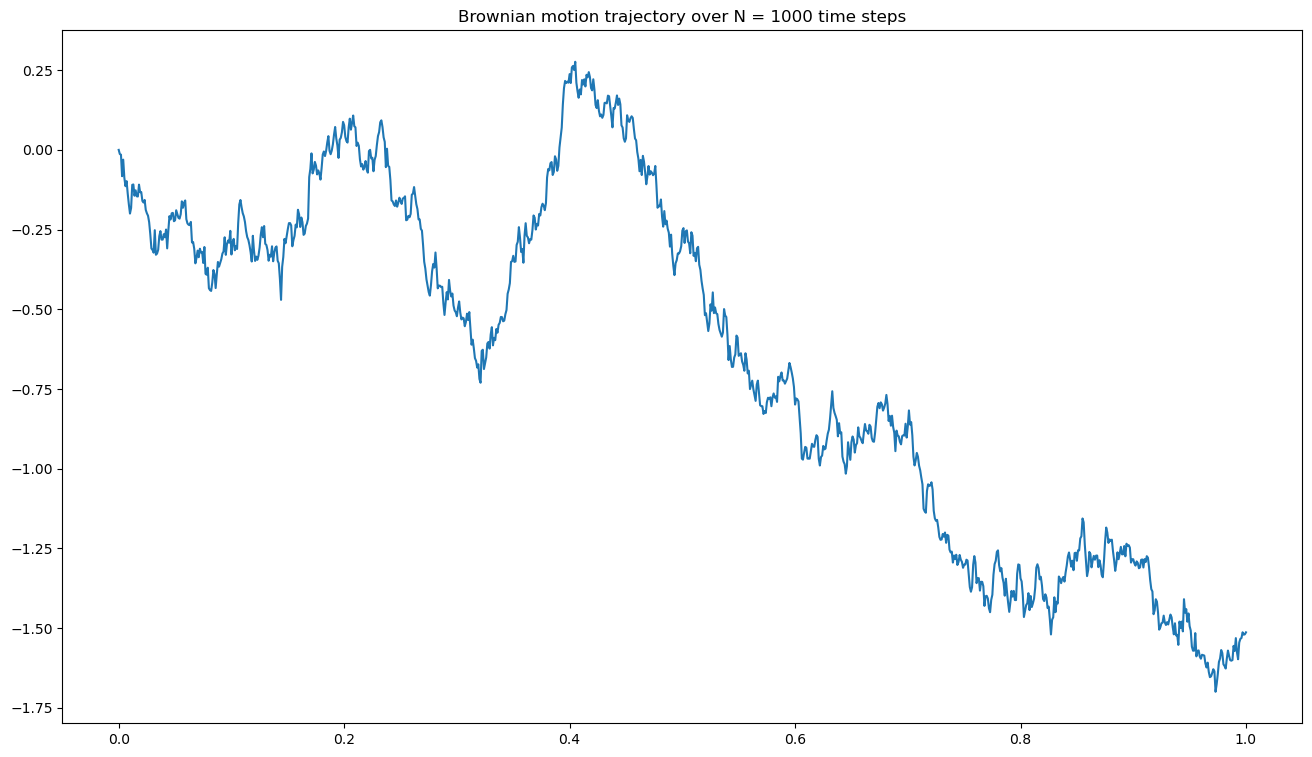

In [28]:
np.random.seed(2)
T = 1. 
N = 1000

time_grid = np.linspace(0, T, N+1)
# N gaussienne N(0,1)
Z = np.random.randn(N)
Y = np.sqrt(T/N)*Z
Y = np.concatenate(([0.], Y))
#genere (W_0, W_t_1, ... W_{t_N})
W = np.cumsum(Y)


plt.plot(time_grid, W, label="")
plt.title("Brownian motion trajectory over N = %1.0f time steps" %N)
plt.show()

In [4]:
np.random.seed(2)
T = 1. 
N = 10

time_grid = np.linspace(0, T, N+1)
print('time_grid:', time_grid)

# N gaussienne N(0,1)
Z = np.random.randn(N)
print('Z:', Z)

#(Y_1,...,Y_N)
Y = np.sqrt(T/N)*Z
print('Y:',Y)

Y = np.concatenate(([0.], Y))
print('Y:',Y)

#genere (W_0, W_t_1, ... W_{t_N})
W = np.cumsum(Y)


time_grid: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
Z: [-0.41675785 -0.05626683 -2.1361961   1.64027081 -1.79343559 -0.84174737
  0.50288142 -1.24528809 -1.05795222 -0.90900761]
Y: [-0.1317904  -0.01779313 -0.67552452  0.51869917 -0.56713413 -0.26618389
  0.15902507 -0.39379467 -0.33455387 -0.28745345]
Y: [ 0.         -0.1317904  -0.01779313 -0.67552452  0.51869917 -0.56713413
 -0.26618389  0.15902507 -0.39379467 -0.33455387 -0.28745345]


2. Let  $t_0 > 0$, and $c > 0$.
Plot the following processes
    <ul>
    <li>$X^1= \left(-W_t\right)_{t \geq 0}$ </li>
    <li>$X^2 = \left(c^{-1/2}W_{ct}\right)_{t \geq 0}$</li>
    <li>$X^3= \left(W_{t + t_0} - W_{t_0}\right)_{t \geq 0}$ </li>
    <li>$X^4 =\left(W_{T - t} - W_T\right)_{t \geq 0}$ </li>
    <li>$X^5_0 := 0$ and $X^5_t := tW_{1/t}, t > 0$</li>
    </ul>


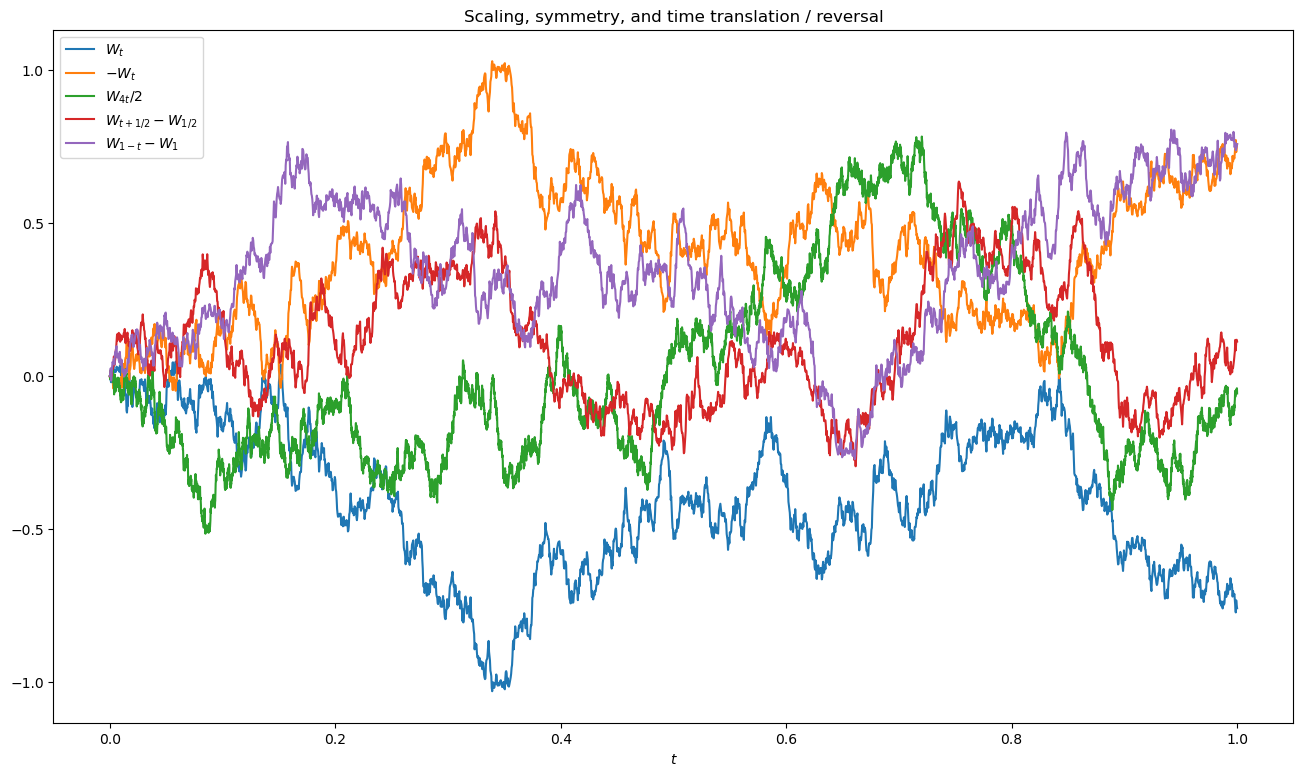

In [38]:
import numpy as np
import matplotlib.pyplot as plot
plot.rcParams['figure.figsize'] = [16, 9]
 
m = 10000
c = 4

dW = np.random.normal(0, 2/np.sqrt(m), m)
W0 = np.concatenate([np.zeros(1), dW.cumsum()])                          #discritized Brownian Motion
W = W0[0:(m//4+1)]
W_sym = -W          
W_scale = 0.5*W0
W_trans = W0[(m//8):(m//8 + m//4+1)] - W0[m//8]
W_rev = np.flip(W) - W[m//4]

plot.plot(np.linspace(0, 1, m//4+1), W)
plot.plot(np.linspace(0, 1, m//4+1), W_sym)
plot.plot(np.linspace(0, 1, m+1), W_scale)
plot.plot(np.linspace(0, 1, m//4+1), W_trans)
plot.plot(np.linspace(0, 1, m//4+1), W_rev)
plot.title("Scaling, symmetry, and time translation / reversal")
plot.xlabel("$t$")
plot.legend(["$W_t$", "$-W_t$", "$W_{4t}/2$", "$W_{t + 1/2} - W_{1/2}$", "$W_{1-t} - W_{1}$"])
plot.show()

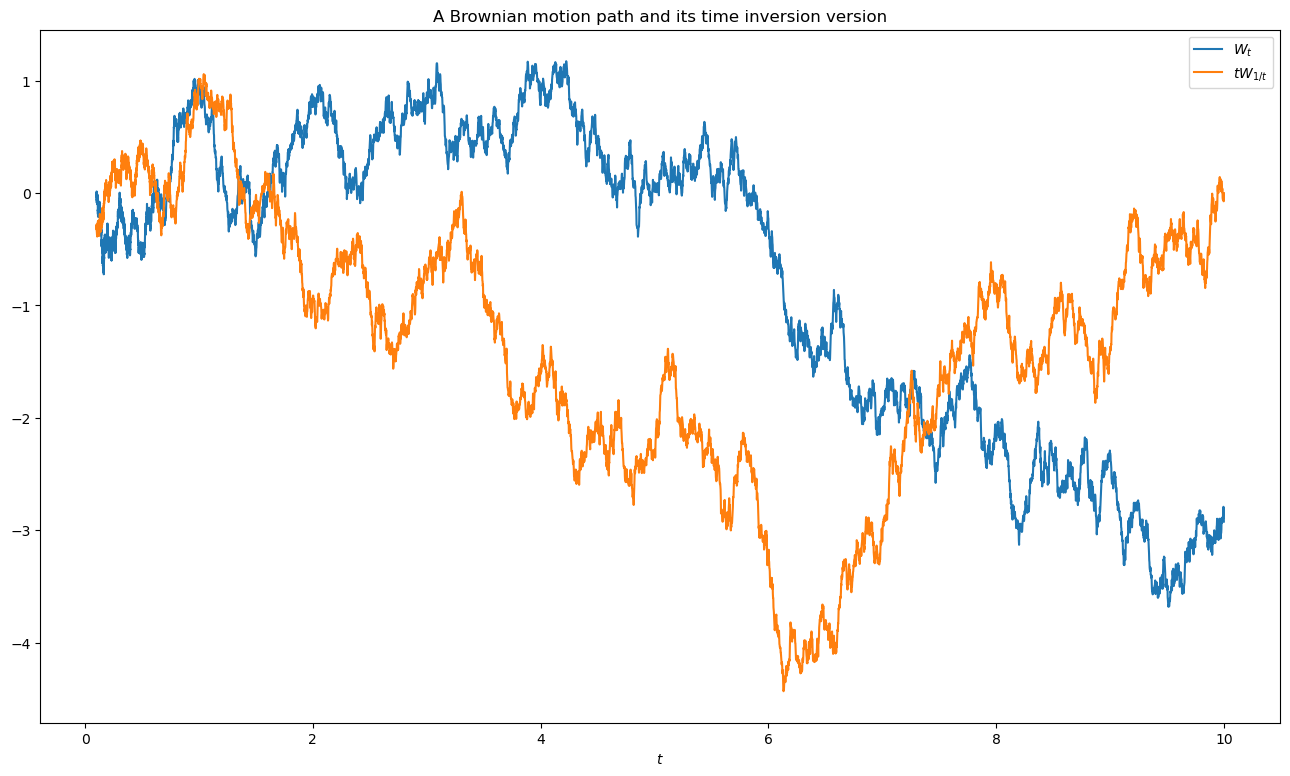

In [2]:
import numpy as np
import matplotlib.pyplot as plot
plot.rcParams['figure.figsize'] = [16, 9]

T = 10.
m = 5000
tp = np.linspace(1, T, m)               #size m
tm = np.flip(1/tp)
t = np.concatenate([tm, tp[1:m]])       #size 2*m - 1
dt = t[1:(2*m-1)] - t[0:(2*m-2)]          #size 2*m - 2

dW = np.random.normal(0, np.sqrt(dt), 2*m-2)

W = np.concatenate([np.zeros(1), dW.cumsum()])
B = t*np.flip(W)

plot.plot(t, W)
plot.plot(t, B)
plot.xlabel("$t$")
plot.legend(["$W_t$", "$tW_{1/t}$"])
plot.title("A Brownian motion path and its time inversion version")
plot.show()


3. Based on the plots, what can you conjecture on these processes? Prove it.

> <p><strong><span style="color:rgb(0, 0, 255);">      All of these processes are again Brownian motion, they can be obtained by verifying that these processes are centered Gaussian processes with the appropriate covariance function.  
</span><strong></p> 


    
<div style="float: left;">
  <img src="images/corrTD3(1).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
</div>
<div style="float: left;">
  <img src="images/corrTD3(2).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>
<div style="float: left;">
  <img src="images/corrTD3(3).jpg" alt="Transposition of a vector" title="Vector transposition" width="250">
 </div>


<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;"> 4. Stochastic integral  $∫_📐 dW$  </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

1. Show that  the total (one) variation of the Brownian motion is infinite:
 $$
\lim_{n\to\infty} \sum_{i\ge 1} \left| W_{t^n_i\wedge t}-W_{t_{i-1}^n\wedge t} \right| = \infty \quad \text{in } L^2.
 $$


2. Let $(\theta)_{t\geq 0}$ be an elementary process.
   
   (i) Prove that $(\int_0^t \theta_s dW_s)_{t\geq 0}$ and $((\int_0^t \theta_s dW_s)^2 - \int_0^t \theta_s^2 ds)$ are  martingales with respect to the Brownian filtration. 
    
   
   (ii) Compute $\mathbb E [(\int_0^T \theta_s dW_s)^2]$
   
   (iii)  Assume that $\theta$ is determinstic. Provide the law of $\int_0^T \theta_s dW_s$.  
   
3. Let $f,g$ be a measurable function such that $\int_0^T f^2(s) ds <\infty$ and $\int_0^T g^2(s) ds<\infty$. What can you say about the distribution of $\int_0^T f(s)dW_s$? What about $\mbox{Cov}(\int_0^T g(s)dW_s, \int_0^T f(s)dW_s)$?
   
    
       
       

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;"> 5. Itô Vs Stratonovich  ⚔️  </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

Let $W$ be a Brownian motion and $t_i=i/T$, $i=0,1,\ldots, n$ a partition of $[0,T]$.

Denote by $$X_t = \sum^{n-1}_{i=0} W_{t_i}(W_{t_{i+1}\wedge t} - W_{t_i \wedge t}), \quad Y_t = \sum^{n-1}_{i=0} \frac{W_{t_i} + W_{t_{i+1}}}{2} (W_{t_{i+1}\wedge t} - W_{t_i \wedge t}).$$

1. Plot on the same graph a sample path of $X$, $Y$, $(X-Y)$ and the function $t\mapsto t/2$. 

2. Comment. What can you conjecture on the relation between $X,Y$ and $t\mapsto t$?
3. Prove the result mathematically. 
4. By approximating $W$ by $W^n_t = \sum_{i=0}^{n-1} W_{t_i} 1_{]t_i, t_{i+1}]} (t) $ compute 
$ \int_0^T W_s dW_s $. 

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;"> 6. First look at Black-Scholes</h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

No interest in the community in the work of Bachelier, although the Russian mathematician  Kolmogorov has cited Bachelier... Growing interest starting 1960s, Robert Merton,  Fisher Black and Myron Scholes model

<img src="images/BS.jpg" alt="Transposition of a vector" title="Vector transposition" width="500">


Scholes received the 1997 Nobel Memorial Prize in Economic Sciences, Black  wasn't awarded because he died in 1995.





Let $W$ be a scalar Brownian motion and $S_t=S_0e^{\int_0^t(r-\frac{\sigma^2}{2})(s)ds+\int_0^t\sigma(s)dW_s}$, for some constant $S_0>0$, and some deterministic functions $r$ and $\sigma$. 
  
  <ol>
<li>Provide an explicit expression of $\mathbb{P}[S_T\ge K]$ for some $K>0$ in terms of the cdf $\mathbf{N}$ of the standard $\mathcal{N}(0,1)$ distribution.</li>
<li> Provide an explicit expression of $\mathbb{E}[e^{-\int_0^T r(s)ds}(S_T-K)^+]$.
<li> Prove that $S$ solves a stochastic differential equation. 

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;"> 7. Itô's formula and heat equation 🔥 </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

Use the Ito formula to write each of the following stochastic processes $(X_t)_{t\geq 0}$ as Itô
processes:

1. $X_t = e^{t/2}\cos(W_t)$
    
2. $X_t = e^{t/2} sin(W_t)$
    
3. $X_t = (W_t + t)e^{-W_t -  t/2}$


<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;"> 8. Lévy's characterization of Brownian motion 🤯 </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

Let $W$ be a Brownian motion, and $\theta$ measurable with respect to $(\mathcal F^W_t)_{t\geq 0}$ be such that $\theta_t^2  = 1 $ for all $t\geq 0$. Show that the process
 $$
 X_t \;:=\; \int_0^t \theta_s dW_s, ~~ j=1,\ldots,n
 $$
is a Brownian motion with respect to the filtration $(\mathcal F^W_t)_{t\geq 0}$.


 


<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;"> 9. From the Ornstein-Uhlenbeck process to the square-root process </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

Fix a Brownian motion $W$ and $a$ and $b$ reals. Consider the stochastic differential equation (SDE) : 
$$ dX_t = a X_t dt + b dW_t, \quad X_0 \in \mathbb R $$

1. Argue the existence and uniqueness of a solution. 
2. Solve the SDE explicitely. 
3. Simulate a trajectory of $X$ for $a>0$ and $a<0$. What other methods can be used to simulate to trajectory of $X$? Comment.  
4. What is the distribution of $X_T$?
5. Define $Y:=X^2$. Derive the dynamics for $Y$
6. Show that $Y$ is also a solution to an SDE. 

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;"></div>

<a id="fbm"></a><h1 style="text-align:center;"> References 📖  </h1>

<div style="background-color: rgb(0, 62, 92); height:10px; margin-top:25px; margin-bottom:25px;">

</div>

$\bullet$ Shreeve, S. E. (2004). Stochastic Calculus for Finance II: Continuous Time Models.